# 🎨 Part 1: PixArt-Sigma Ink-Wash LoRA — Data Preparation & 20-Step Style Teacher Evaluation
### *Master Evaluation Guide: Data & Precomputed Feature Caching Inspection, Style Teacher Model Verification (`models/best_ink_wash_lora_plant209_step4000`), Step 0 Baseline vs. Teacher Evaluation Curves, and Visual Progression*

---

### 📌 Overview & Scope
This notebook focuses purely on **evaluation, asset contract validation, and visual analysis** for the data preparation and 20-step Style Teacher model:
1. **System & Environment Diagnostics**: CUDA availability, GPU VRAM monitoring, and PyTorch runtime.
2. **Data & Precomputed Feature Inspection**:
   - Inspecting raw dataset archives (`data/archives/ink.zip` / `data/ink_legacy.zip`).
   - Validating precomputed SDXL VAE clean latents (`data/archives/clean_latents_512.zip`) and 300-token T5-XXL FP16 embeddings (`data/features/t5_embeddings_*.pt`).
3. **Style Teacher Adapter Validation (`models/best_ink_wash_lora_plant209_step4000`)**:
   - Structural contract verification: **574 FP32 tensors** and **13,765,376 parameters** across 12 linear projection target modules.
4. **Style Teacher vs. Step 0 Baseline Metric Evaluation**:
   - 10,000-step training trajectory analysis (CLIPScore alignment progression).
   - Category-wise benchmark evaluation across 4 traditional themes (Landscapes, Flora & Fauna, Minimalist, Architecture).
5. **Visual Progression Gallery**:
   - Side-by-side progression from Step 0 Baseline to Step 10,000 Teacher checkpoints.


## 0. 🛠️ Environment Diagnostics & Repository Resolution
Verify the `pixart311` conda environment and CUDA GPU hardware.


In [1]:
import os
import sys
import gc
import json
import time
import math
import csv
import statistics
import hashlib
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def get_repo_root() -> Path:
    curr = Path.cwd().resolve()
    for parent in [curr] + list(curr.parents):
        if (parent / "README.md").is_file() and (parent / "scripts").is_dir():
            return parent
    return curr

REPO_ROOT = get_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"[*] Repository Root: {REPO_ROOT}")
print(f"[*] Python Version:  {sys.version.split()[0]}")
print(f"[*] PyTorch Version: {torch.__version__}")
print(f"[*] CUDA Available:  {torch.cuda.is_available()}")

if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"[*] GPU Device:      {device_name} ({vram_gb:.2f} GB VRAM)")
else:
    print("[!] Running in CPU-only mode.")


[*] Repository Root: C:\dev\efficient-pixart-sigma-lora
[*] Python Version:  3.11.15
[*] PyTorch Version: 2.5.1+cu121
[*] CUDA Available:  True
[*] GPU Device:      NVIDIA GeForce RTX 4070 (11.99 GB VRAM)


## 1. 📂 Stage 0: Data & Precomputed Feature Caching Inspection
Inspect the raw ink-wash archive and precomputed features:
- **Clean Latents**: SDXL VAE $4 	imes 64 	imes 64$ FP16 latents.
- **T5-XXL Embeddings**: 300 tokens, 4096-dim FP16 embeddings.


In [2]:
from scripts.distillation.common import MANIFEST_FINGERPRINT
from scripts.training.train_local_latent_lora import load_latent_bundle
import zipfile

raw_archive = REPO_ROOT / "data" / "archives" / "ink.zip"
legacy_archive = REPO_ROOT / "data" / "ink_legacy.zip"
latent_archive = REPO_ROOT / "data" / "archives" / "clean_latents_512.zip"
t5_cache_file = REPO_ROOT / "data" / "features" / f"t5_embeddings_n260_len300_fp16_{MANIFEST_FINGERPRINT}.pt"

print("[*] Inspecting Stage 0 Feature Assets...")
target_raw = raw_archive if raw_archive.is_file() else legacy_archive
print(f"   * Raw Archive:   {target_raw.name} -> Exists: {target_raw.is_file()}")
print(f"   * Clean Latents: {latent_archive.name} -> Exists: {latent_archive.is_file()}")
print(f"   * T5 Cache:      {t5_cache_file.name} -> Exists: {t5_cache_file.is_file()}")

if target_raw.is_file():
    with zipfile.ZipFile(target_raw, "r") as zf:
        imgs = [f for f in zf.namelist() if f.endswith(('.png', '.jpg', '.jpeg'))]
        print(f"   [+] Raw Images:   {len(imgs)} items found in archive")

if latent_archive.is_file():
    latents, manifests = load_latent_bundle(latent_archive, plant_only=True)
    sample_k = next(iter(latents))
    print(f"   [+] Clean Latents: {len(latents)} plant samples (Tensor Shape: {tuple(latents[sample_k].shape)})")

if t5_cache_file.is_file():
    t5_data = torch.load(t5_cache_file, map_location="cpu", weights_only=True)
    print(f"   [+] T5 Embeddings: {t5_data['prompt_embeds'].shape} (dtype: {t5_data['prompt_embeds'].dtype})")


[*] Inspecting Stage 0 Feature Assets...
   * Raw Archive:   ink_legacy.zip -> Exists: True
   * Clean Latents: clean_latents_512.zip -> Exists: False
   * T5 Cache:      t5_embeddings_n260_len300_fp16_b9d3c2d1d404.pt -> Exists: True
   [+] Raw Images:   249 items found in archive
   [+] T5 Embeddings: torch.Size([260, 300, 4096]) (dtype: torch.float16)


## 2. 🎓 Stage 1: Style Teacher LoRA Model Inspection (`models/`)
Inspect the Style Teacher adapter located in `models/best_ink_wash_lora_plant209_step4000`.
- **Rank**: 16, **Alpha**: 16
- **Architecture**: 12 linear projection target modules
- **Contract**: Exactly 574 FP32 tensors and 13,765,376 adapter parameters.


In [3]:
from scripts.distillation.validate_style_teacher_impl import inspect_adapter

# Primary Teacher model path in models/
teacher_dir = REPO_ROOT / "models" / "best_ink_wash_lora_plant209_step4000"
if not teacher_dir.is_dir():
    teacher_dir = REPO_ROOT / "outputs" / "style_teacher" / "plant_n209_steps10200" / "r16_lr1e-05"

print(f"[*] Style Teacher Path: {teacher_dir}")

if teacher_dir.exists():
    inspection = inspect_adapter(teacher_dir)
    print("\n[+] Teacher Adapter Contract Inspection:")
    print(f"   * Rank:             {inspection['rank']}")
    print(f"   * LoRA Alpha:       {inspection['lora_alpha']}")
    print(f"   * Tensor Count:     {inspection['tensor_count']} (Expected: 574)")
    print(f"   * Parameter Count:  {inspection['parameter_count']:,} (Expected: 13,765,376)")
    print(f"   * Weights SHA256:   {inspection['adapter_sha256'][:16]}...")
    print(f"   * Target Modules:   {', '.join(inspection['target_modules'][:4])}... ({len(inspection['target_modules'])} total)")
else:
    print(f"[!] Style Teacher directory not found at {teacher_dir}")


[*] Style Teacher Path: C:\dev\efficient-pixart-sigma-lora\models\best_ink_wash_lora_plant209_step4000

[+] Teacher Adapter Contract Inspection:
   * Rank:             16
   * LoRA Alpha:       16
   * Tensor Count:     574 (Expected: 574)
   * Parameter Count:  13,765,376 (Expected: 13,765,376)
   * Weights SHA256:   ad300d2a84bfb686...
   * Target Modules:   ff.net.0.proj, ff.net.2, linear, linear_1... (12 total)


## 3. 📊 Stage 1.5: Teacher Model vs. Step 0 Baseline Evaluation Curves
Evaluate text-image alignment (**CLIPScore**) from Step 0 Baseline to Step 10,000 across dataset sizes.


[*] 10k Training & Baseline Evaluation Table:


,dataset,num_images,rank,step,guidance_scale,clip_score,latency_sec,image_path
0,baseline,0,0,0,1.5,0.383973,22.0600,outputs\experiment_10k\eval_generations\baseli...
12,n100,100,16,1000,1.5,0.392452,17.1765,outputs\experiment_10k\eval_generations\n100\s...
13,n100,100,16,2000,1.5,0.385233,17.5934,outputs\experiment_10k\eval_generations\n100\s...
14,n100,100,16,3000,1.5,0.380116,17.4879,outputs\experiment_10k\eval_generations\n100\s...
15,n100,100,16,4000,1.5,0.379197,17.3727,outputs\experiment_10k\eval_generations\n100\s...
16,n100,100,16,5000,1.5,0.376884,17.0113,outputs\experiment_10k\eval_generations\n100\s...
17,n100,100,16,6000,1.5,0.376843,17.7862,outputs\experiment_10k\eval_generations\n100\s...
18,n100,100,16,7000,1.5,0.371397,18.4390,outputs\experiment_10k\eval_generations\n100\s...
19,n100,100,16,8000,1.5,0.350971,17.7064,outputs\experiment_10k\eval_generations\n100\s...
20,n100,100,16,9000,1.5,0.372287,17.7531,outputs\experiment_10k\eval_generations\n100\s...


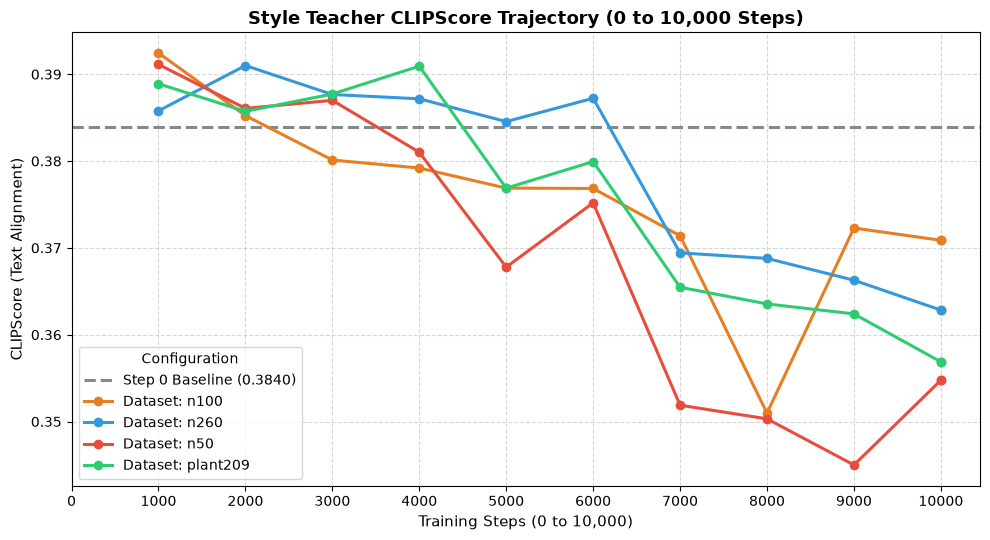

In [4]:
metrics_csv = REPO_ROOT / "outputs" / "experiment_10k" / "metrics_10k.csv"

if metrics_csv.is_file():
    df_10k = pd.read_csv(metrics_csv)
    print("[*] 10k Training & Baseline Evaluation Table:")
    display(df_10k.sort_values(["dataset", "step"]))
    
    # Plot Step 0 Baseline vs Training Checkpoints
    plt.figure(figsize=(10, 5.5))
    colors = {"baseline": "#7f8c8d", "n50": "#e74c3c", "n100": "#e67e22", "plant209": "#2ecc71", "n260": "#3498db"}
    
    base_df = df_10k[df_10k["dataset"] == "baseline"]
    base_score = base_df["clip_score"].values[0] if not base_df.empty else None
    
    if base_score is not None:
        plt.axhline(y=base_score, color=colors["baseline"], linestyle="--", linewidth=2.2, label=f"Step 0 Baseline ({base_score:.4f})")
        
    for dataset_name, group in df_10k.groupby("dataset"):
        if dataset_name == "baseline":
            continue
        grp = group.sort_values("step")
        plt.plot(grp["step"], grp["clip_score"], marker="o", linewidth=2.2, color=colors.get(dataset_name, "purple"), label=f"Dataset: {dataset_name}")
        
    plt.title("Style Teacher CLIPScore Trajectory (0 to 10,000 Steps)", fontsize=13, fontweight="bold")
    plt.xlabel("Training Steps (0 to 10,000)", fontsize=11)
    plt.ylabel("CLIPScore (Text Alignment)", fontsize=11)
    plt.xticks(range(0, 11000, 1000))
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Configuration", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print(f"[!] {metrics_csv} not found.")


## 4. 🎯 Stage 1.6: 30-Prompt Category Benchmark Evaluation
Evaluation of the best Style Teacher checkpoint against 30 fixed benchmark prompts across 4 traditional themes.


[*] 30-Prompt Benchmark Summary (CLIPScore & CMMD Distance):


,model_id,model_name,avg_clip_score,cmmd_score
3,plant209_best,Best plant209 (Step 4000),0.360187,0.001229
4,n260_best,Best n260 (Step 2000),0.353863,0.001445
2,n100_best,Best n100 (Step 1000),0.352484,0.001709
1,n50_best,Best n50 (Step 1000),0.349272,0.001762
0,baseline,Baseline Model (Step 0),0.348983,0.001900



[*] Category Breakdown (Average CLIPScore):


category,Architecture,Flora_Fauna,Landscapes,Minimalist
model_name,,,,
Baseline Model (Step 0),0.347930,0.350726,0.345765,0.351722
Best n100 (Step 1000),0.368983,0.352038,0.355979,0.332499
Best n260 (Step 2000),0.363432,0.352329,0.356894,0.344382
Best n50 (Step 1000),0.366132,0.349780,0.351181,0.329651
Best plant209 (Step 4000),0.368274,0.356617,0.363720,0.352143


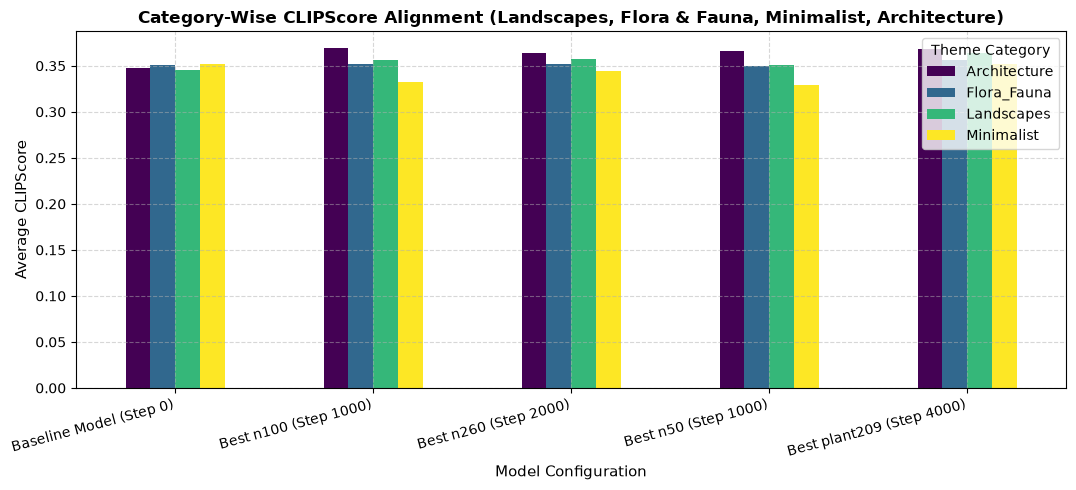

In [5]:
summary_csv = REPO_ROOT / "outputs" / "benchmark_30prompts" / "benchmark_summary.csv"
detail_csv = REPO_ROOT / "outputs" / "benchmark_30prompts" / "benchmark_30prompts_detail.csv"

if summary_csv.is_file():
    df_summary = pd.read_csv(summary_csv)
    print("[*] 30-Prompt Benchmark Summary (CLIPScore & CMMD Distance):")
    display(df_summary.sort_values("cmmd_score"))

if detail_csv.is_file():
    df_detail = pd.read_csv(detail_csv)
    cat_pivot = df_detail.groupby(["model_name", "category"])["clip_score"].mean().unstack()
    print("\n[*] Category Breakdown (Average CLIPScore):")
    display(cat_pivot)
    
    # Plot Category Bar Chart
    cat_pivot.plot(kind="bar", figsize=(11, 5), colormap="viridis")
    plt.title("Category-Wise CLIPScore Alignment (Landscapes, Flora & Fauna, Minimalist, Architecture)", fontsize=12, fontweight="bold")
    plt.ylabel("Average CLIPScore", fontsize=11)
    plt.xlabel("Model Configuration", fontsize=11)
    plt.xticks(rotation=15, ha="right")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(title="Theme Category", fontsize=10)
    plt.tight_layout()
    plt.show()


## 5. 🖼️ Stage 1.7: Visual Progression Gallery (Step 0 Baseline to Step 10,000)
Visual grid showing the emergence of ink-wash brush strokes, negative space, and atmospheric mist.


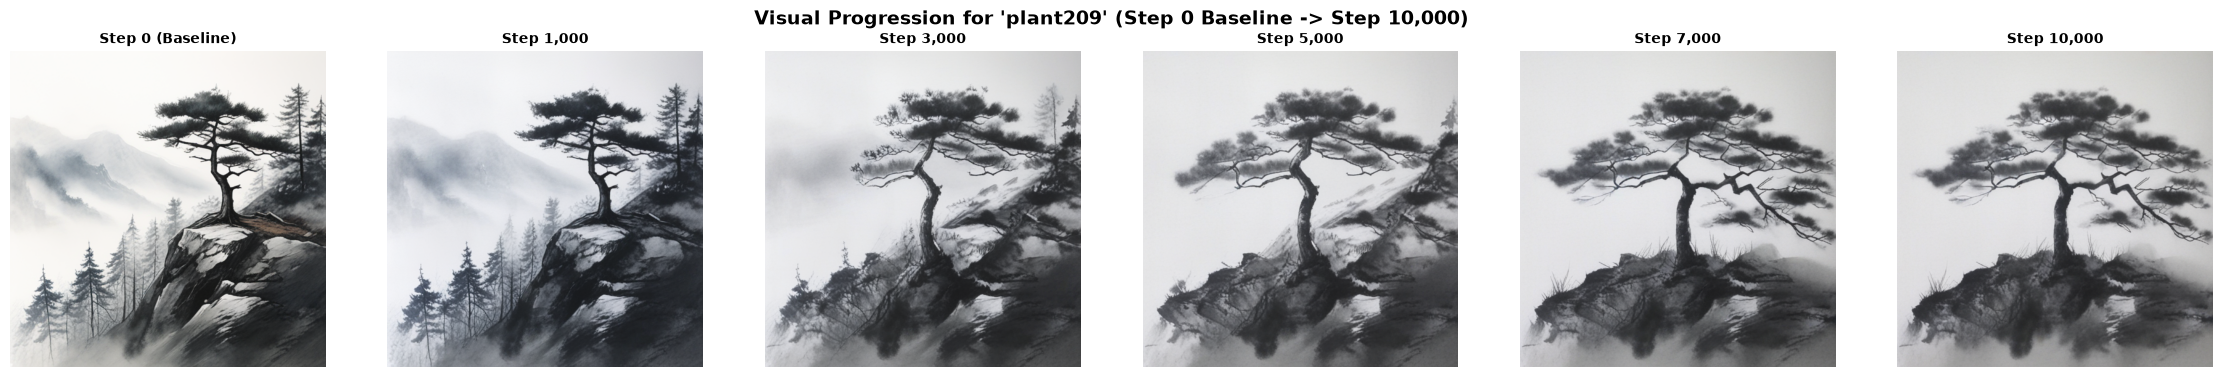

In [6]:
def render_teacher_visual_progression(dataset_name: str = "plant209", steps=[0, 1000, 3000, 5000, 7000, 10000]):
    exp_dir = REPO_ROOT / "outputs" / "experiment_10k"
    fig, axes = plt.subplots(1, len(steps), figsize=(3.8 * len(steps), 3.8))
    fig.suptitle(f"Visual Progression for '{dataset_name}' (Step 0 Baseline -> Step 10,000)", fontsize=14, fontweight="bold")
    
    found_any = False
    for idx, step in enumerate(steps):
        if step == 0:
            img_path = exp_dir / "eval_generations" / "baseline" / "step_0.png"
        else:
            img_path = exp_dir / "eval_generations" / dataset_name / f"step_{step}.png"
            
        if img_path.is_file():
            found_any = True
            img = Image.open(img_path)
            axes[idx].imshow(img)
            title_str = "Step 0 (Baseline)" if step == 0 else f"Step {step:,}"
            axes[idx].set_title(title_str, fontsize=10, fontweight="bold")
            axes[idx].axis("off")
        else:
            axes[idx].text(0.5, 0.5, f"Step {step:,}\n(Pending)", ha="center", va="center", fontsize=10)
            axes[idx].axis("off")
            
    plt.tight_layout()
    if found_any:
        plt.show()
    else:
        plt.close()
        print(f"[*] Visual progression images not yet rendered in {exp_dir / 'eval_generations'}.")

render_teacher_visual_progression("plant209")
